<a href="https://colab.research.google.com/github/rohkdev/ClimateModelingResearch/blob/main/Task%206%3A%20Random%20Forest%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load your station-year dataset
df = pd.read_csv("Random Forest Modeling Data.csv")
df.head()  # Quick check to ensure it loaded correctly

,station_id,year,station_name,latitude,longitude,elevation_m,valid_summer_TMIN_days,warm_night_count,percent_warm_nights,distance_to_coast_km
0,USC00040088,1970,"ALDERPOINT, CA US",40.18333,-123.61667,139.9,122,0,0.0,44.497906
1,USC00040088,1971,"ALDERPOINT, CA US",40.18333,-123.61667,139.9,122,0,0.0,44.497906
2,USC00040088,1972,"ALDERPOINT, CA US",40.18333,-123.61667,139.9,122,0,0.0,44.497906
3,USC00040088,1973,"ALDERPOINT, CA US",40.18333,-123.61667,139.9,120,0,0.0,44.497906
4,USC00040088,1974,"ALDERPOINT, CA US",40.18333,-123.61667,139.9,107,0,0.0,44.497906


In [ ]:
# Select only your numerical features
X = df[
    [
        "latitude",
        "longitude",
        "elevation_m",
        "valid_summer_TMIN_days",
        "distance_to_coast_km",
        "year",
    ]
]

# Define your target variable
y = df["percent_warm_nights"]

In [ ]:
# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
# Initialize and fit the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest model successfully trained!")

Random Forest model successfully trained!


In [ ]:
# Predict on the test set
y_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2) Score: {r2:.4f}")
# original metrics
#Root Mean Squared Error (RMSE): 6.2059
#Mean Absolute Error (MAE): 3.2526
#R-squared (R2) Score: 0.9326

Root Mean Squared Error (RMSE): 5.1511
Mean Absolute Error (MAE): 2.6928
R-squared (R2) Score: 0.9323


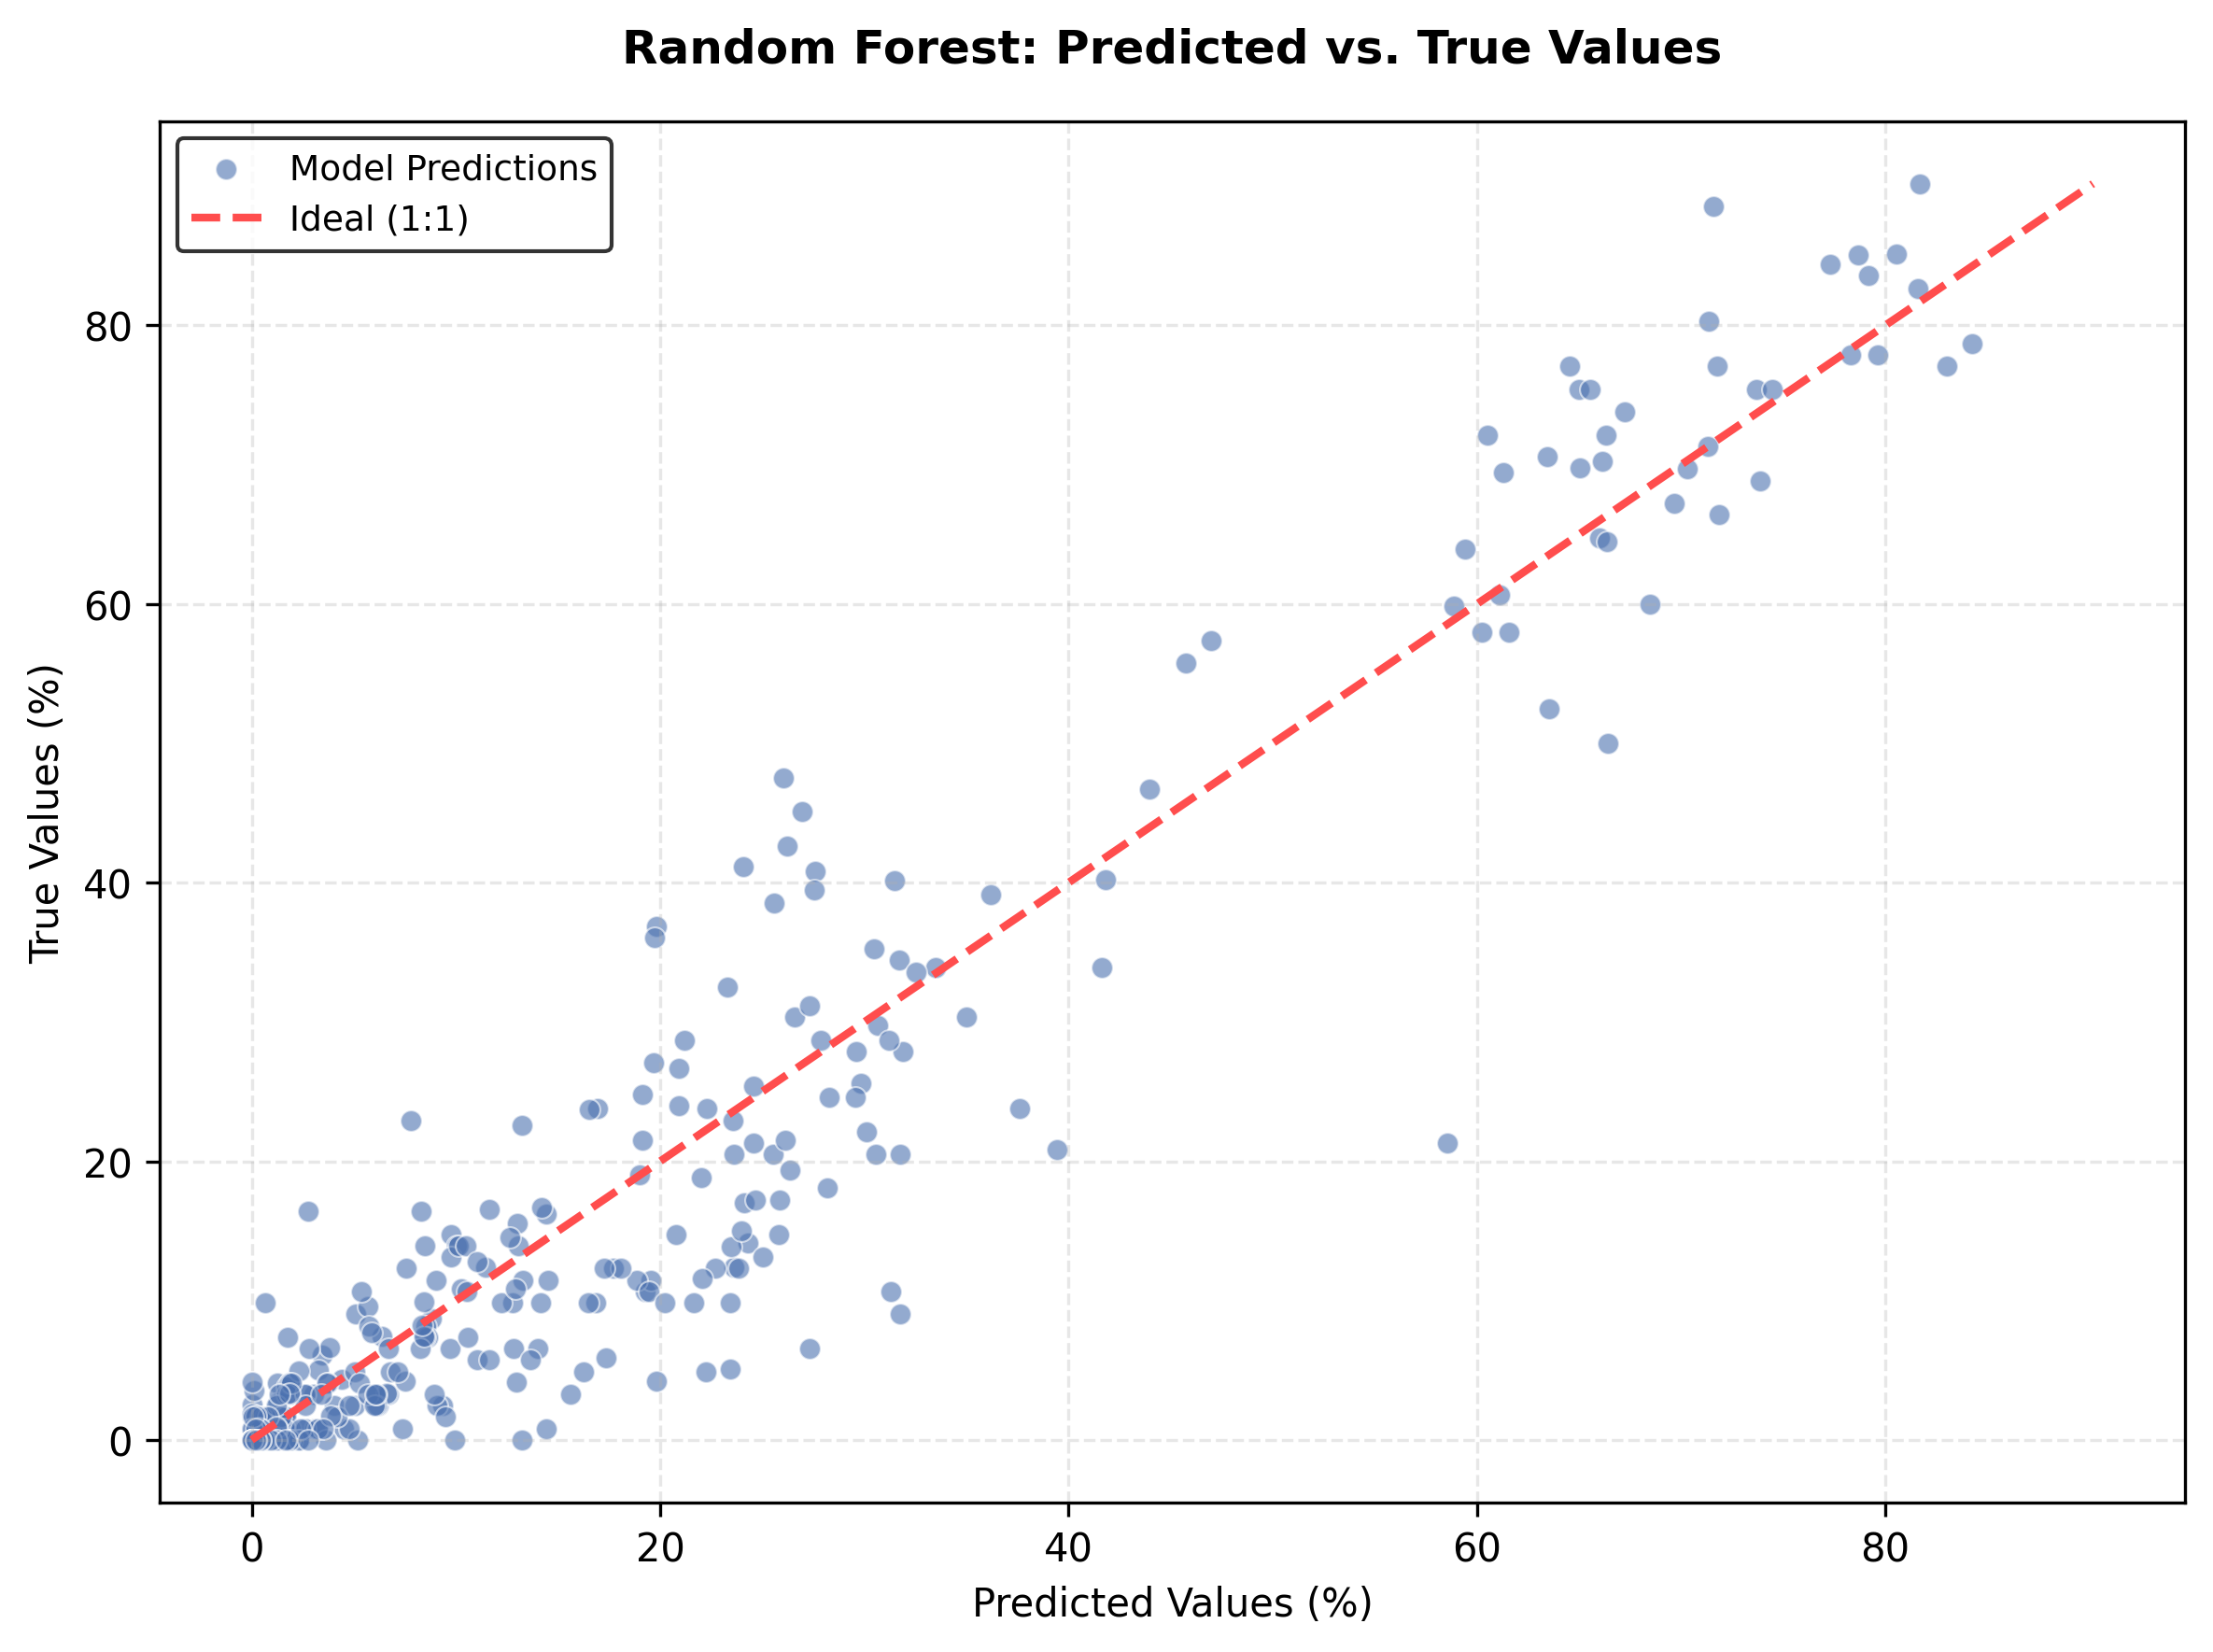

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Initialize figure with white background and high print quality resolution
plt.figure(figsize=(8, 6), dpi=300, facecolor='white')

# Generate the scatterplot
plt.scatter(
    y_pred,
    y_test,
    alpha=0.6,
    color='#4c72b0',
    edgecolor='white',
    linewidth=0.5,
    s=30,
    label='Model Predictions',
)

# Plot the ideal 45-degree reference line (y = x)
min_val = min(min(y_pred), min(y_test))
max_val = max(max(y_pred), max(y_test))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='#ff4d4d',
    linestyle='--',
    lw=2,
    label='Ideal (1:1)',
)

# Formatting titles and labels with percentage units
plt.title('Random Forest: Predicted vs. True Values', fontsize=12, pad=15, fontweight='bold')
plt.xlabel('Predicted Values (%)', fontsize=10)
plt.ylabel('True Values (%)', fontsize=10)

# Clean grid styling and layout adjustments
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, facecolor='white', edgecolor='black', fontsize=9)
plt.tight_layout()

# Save at high print quality
plt.savefig(
    'Figure_RF_Predicted_vs_True_Pct.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
)
plt.show()